# EfficientNet-B3 (Partial Unfreeze)

## Motivation

Previous experiments trained the full EfficientNet-B3 backbone end-to-end. This notebook explores whether freezing early layers (which capture generic low-level features) and only fine-tuning the last few blocks improves generalisation on the small HAM10000 dataset (~7,800 images).

### Setup
| | EfficientNet-B3 Basic | EfficientNet-B3 Partial Unfreeze |
|---|---|---|
| Backbone | Fully unfrozen | Last N blocks only |
| `unfreeze_last_n_blocks` | 0 (all) | configurable |
| Augmentation | Basic (h-flip, ±10° rotation) | Basic (h-flip, ±10° rotation) |
| Optimizer | Adam | Adam |
| LR | 1e-4 | 1e-4 |
| Weight decay | None | None |
| LR scheduler | None | None |

`model.features` has 9 children: `[0]` stem conv, `[1–7]` MBConv blocks, `[8]` head conv.
Set `UNFREEZE_LAST_N_BLOCKS` below to control how many to unfreeze from the end.

In [1]:
# --- Config ---
UNFREEZE_LAST_N_BLOCKS = 3  # unfreeze last 3: MBConv block 6, block 7, head conv
NUM_EPOCHS = 20
LR = 1e-4
BATCH_SIZE = 32
IMAGE_SIZE = 224
MODEL_SAVE_PATH = f'../models/efficientnet_b3_partial_unfreeze_{UNFREEZE_LAST_N_BLOCKS}_best.pth'

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [3]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=0,
)

train_df = pd.read_csv('../data/splits/train.csv')
num_melanoma = (train_df['label'] == 0).sum()
num_nevus = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([6.0244], device='cuda:0')


In [6]:
model = get_efficientnet(num_classes=1, unfreeze_last_n_blocks=UNFREEZE_LAST_N_BLOCKS).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)')

Trainable params: 8,507,615 / 10,697,769 (79.5%)


In [7]:
best_val_f2 = 0.0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_recalls, val_recalls = [], []
train_f2s, val_f2s = [], []

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f'  Saved best model at epoch {epoch+1}')

Epoch [1/20] | Train Loss: 0.8140, Acc: 0.7224, Recall: 0.8845, F2: 0.6582 | Val Loss: 0.6497, Acc: 0.7980, Recall: 0.8383, F2: 0.6876
  Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.5912, Acc: 0.8158, Recall: 0.8858, F2: 0.7302 | Val Loss: 0.5850, Acc: 0.8346, Recall: 0.8383, F2: 0.7179
  Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.5029, Acc: 0.8500, Recall: 0.8922, F2: 0.7641 | Val Loss: 0.6102, Acc: 0.8849, Recall: 0.7725, F2: 0.7215
  Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.4245, Acc: 0.8807, Recall: 0.9204, F2: 0.8104 | Val Loss: 0.6678, Acc: 0.8926, Recall: 0.7425, F2: 0.7086


Epoch [5/20] | Train Loss: 0.3849, Acc: 0.8936, Recall: 0.9255, F2: 0.8266 | Val Loss: 0.6638, Acc: 0.8764, Recall: 0.8144, F2: 0.7407
  Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.1544, Acc: 0.9664, Recall: 0.9653, F2: 0.9342 | Val Loss: 0.9078, Acc: 0.8934, Recall: 0.7605, F2: 0.7216


Epoch [17/20] | Train Loss: 0.1303, Acc: 0.9695, Recall: 0.9833, F2: 0.9490 | Val Loss: 0.9488, Acc: 0.9096, Recall: 0.7545, F2: 0.7334


Epoch [18/20] | Train Loss: 0.1178, Acc: 0.9730, Recall: 0.9795, F2: 0.9511 | Val Loss: 1.0861, Acc: 0.9250, Recall: 0.7246, F2: 0.7280


Epoch [19/20] | Train Loss: 0.1148, Acc: 0.9711, Recall: 0.9807, F2: 0.9495 | Val Loss: 1.0104, Acc: 0.9113, Recall: 0.7725, F2: 0.7474


Epoch [20/20] | Train Loss: 0.1112, Acc: 0.9744, Recall: 0.9807, F2: 0.9538 | Val Loss: 1.0994, Acc: 0.9250, Recall: 0.7305, F2: 0.7323


## Plot Loss and Accuracy Curves

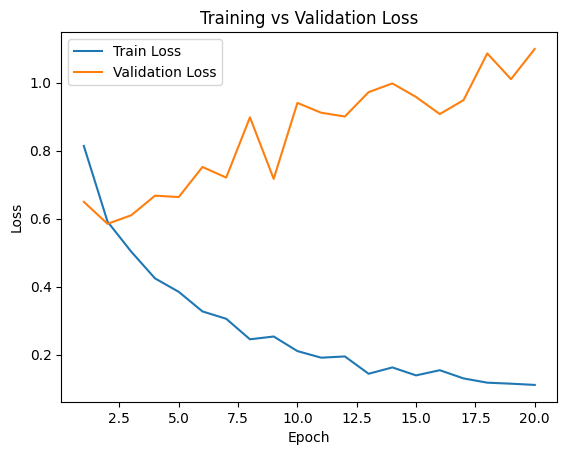

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

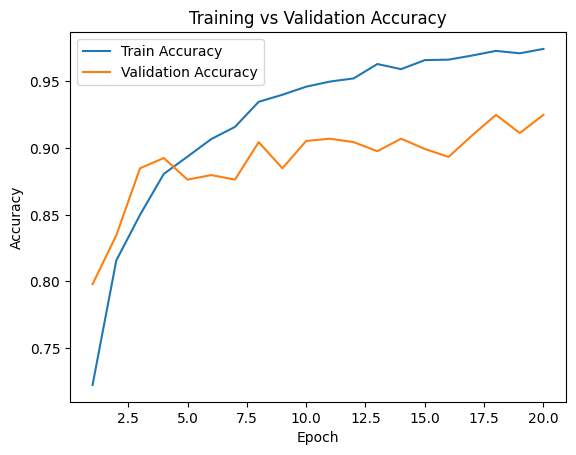

In [9]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

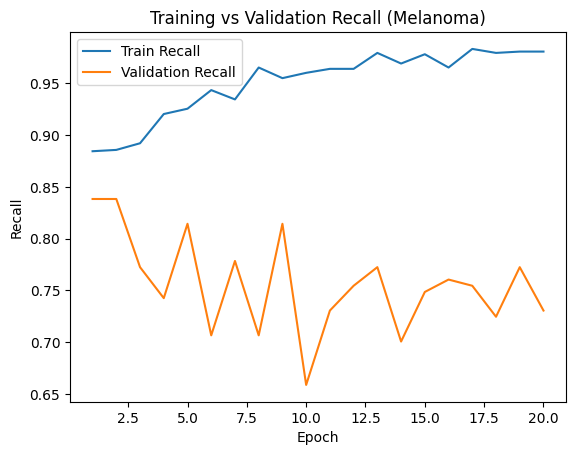

In [10]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

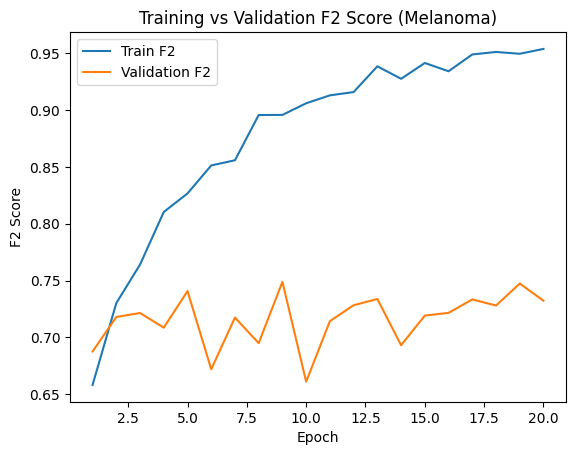

In [11]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [12]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.42 | Val F2: 0.7655


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [14]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[885 121]
 [ 24 143]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [15]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9736    0.8797    0.9243      1006
           1     0.5417    0.8563    0.6636       167

    accuracy                         0.8764      1173
   macro avg     0.7576    0.8680    0.7939      1173
weighted avg     0.9121    0.8764    0.8872      1173



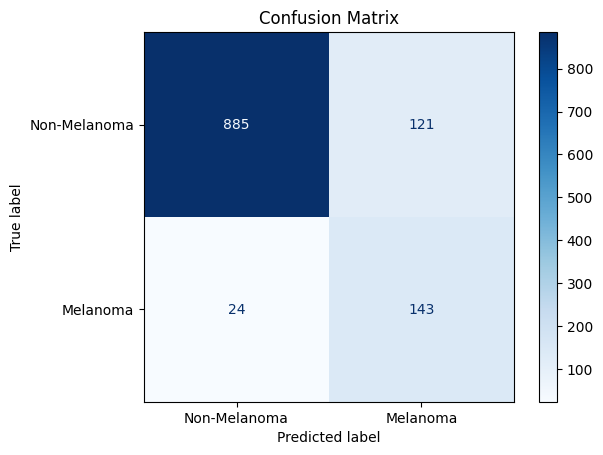

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()